In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

V = json.load(open("e14_verify.json"))
CA = V["certified_accuracy_strict"]
CA_CI = V.get("certified_accuracy_ci_aware", [])
FLAGS = V["cross_method_agreement"]["per_point_flags"]
SUMM = V["rcert_summary"]

C = {"strict": "#2980b9", "ci": "#8e44ad", "target": "#c0392b",
     "concord": "#27ae60", "dissoc": "#e67e22", "cohen": "#16a085"}
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True, "grid.alpha": 0.3})
print(f"in-scope points: {V['n_in_scope_points']} | frozen reproduction EXACT: "
      f"{V['gate_frozen_repro']['exact_reproduction']} ({V['gate_frozen_repro']['n_checked']} cells) | "
      f"non-monotone curves: {V['n_nonmonotone']}")

in-scope points: 8 | frozen reproduction EXACT: True (8 cells) | non-monotone curves: 4


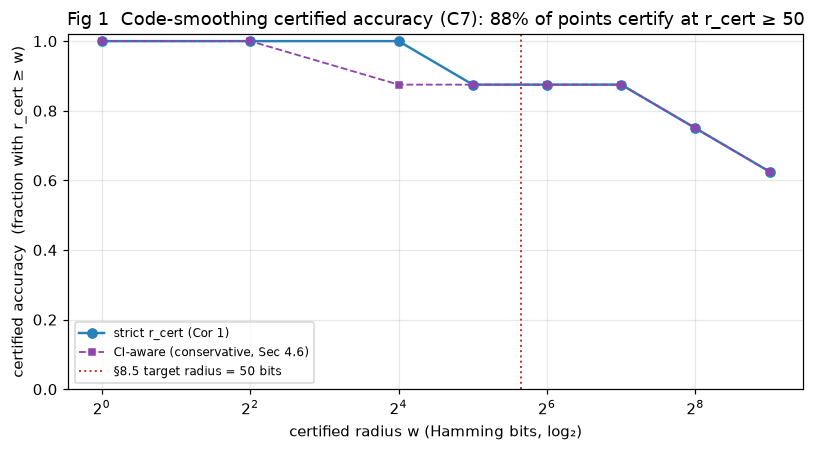

strict r_cert: median=512  min=16  max=512  frac≥50=87.5%


In [2]:
rad = [p["radius"] for p in CA]
acc = [p["certified_accuracy"] for p in CA]
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(rad, acc, "-o", color=C["strict"], lw=1.6, label="strict r_cert (Cor 1)")
if CA_CI:
    ax.plot([p["radius"] for p in CA_CI], [p["certified_accuracy"] for p in CA_CI],
            "--s", color=C["ci"], lw=1.2, ms=4, label="CI-aware (conservative, Sec 4.6)")
ax.axvline(50, color=C["target"], ls=":", lw=1.3, label="§8.5 target radius = 50 bits")
ax.set_xscale("log", base=2)
ax.set_xlabel("certified radius w (Hamming bits, log₂)")
ax.set_ylabel("certified accuracy  (fraction with r_cert ≥ w)")
ax.set_ylim(0, 1.02)
ax.set_title(f"Fig 1  Code-smoothing certified accuracy (C7): "
             f"{SUMM['frac_rcert_ge_50']:.0%} of points certify at r_cert ≥ 50")
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout(); plt.show()
print(f"strict r_cert: median={SUMM['r_cert_median']:.0f}  min={SUMM['r_cert_min']:.0f}  "
      f"max={SUMM['r_cert_max']:.0f}  frac≥50={SUMM['frac_rcert_ge_50']:.1%}")

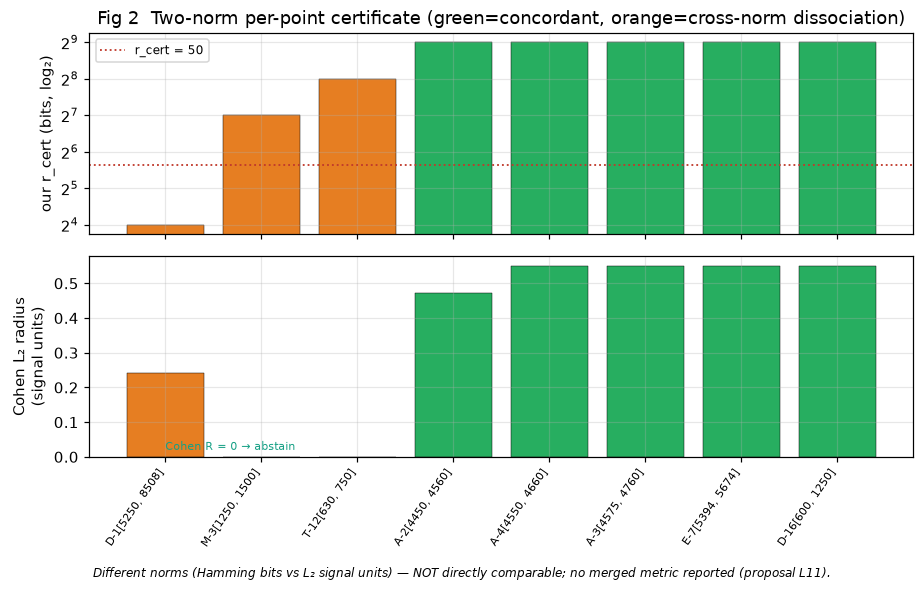

cross-norm: concordant=5/8 (both-robust=5, both-fragile=0); dissociate=3


In [3]:
ids = [f["point_id"] for f in FLAGS]
rcerts = [max(f["r_cert"], 1) for f in FLAGS]
cohenR = [f["cohen_R"] for f in FLAGS]
concord = [(f["ours_fragile_rcert_lt50"] == f["cohen_abstain"]) for f in FLAGS]
cols = [C["concord"] if c else C["dissoc"] for c in concord]
order = np.argsort(rcerts)
ids = [ids[i] for i in order]; rcerts = [rcerts[i] for i in order]
cohenR = [cohenR[i] for i in order]; cols = [cols[i] for i in order]
x = np.arange(len(ids))

fig, ax = plt.subplots(2, 1, figsize=(8.5, 5.2), sharex=True)
ax[0].bar(x, rcerts, color=cols, edgecolor="k", linewidth=0.3)
ax[0].axhline(50, color=C["target"], ls=":", lw=1.2, label="r_cert = 50")
ax[0].set_yscale("log", base=2); ax[0].set_ylabel("our r_cert (bits, log₂)")
ax[0].set_title("Fig 2  Two-norm per-point certificate (green=concordant, orange=cross-norm dissociation)")
ax[0].legend(fontsize=8)
ax[1].bar(x, cohenR, color=cols, edgecolor="k", linewidth=0.3)
ax[1].set_ylabel("Cohen L₂ radius\n(signal units)")
ax[1].set_xticks(x); ax[1].set_xticklabels(ids, rotation=55, ha="right", fontsize=7)
ax[1].annotate("Cohen R = 0 → abstain", (0, 0.02), fontsize=7, color=C["cohen"])
fig.text(0.5, -0.02, "Different norms (Hamming bits vs L₂ signal units) — NOT directly comparable; "
         "no merged metric reported (proposal L11).", ha="center", fontsize=8, style="italic")
plt.tight_layout(); plt.show()

cma = V["cross_method_agreement"]
print(f"cross-norm: concordant={cma['both_robust']+cma['both_fragile']}/{len(FLAGS)} "
      f"(both-robust={cma['both_robust']}, both-fragile={cma['both_fragile']}); "
      f"dissociate={len(FLAGS)-(cma['both_robust']+cma['both_fragile'])}")